In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


df=pd.read_csv('agridata.csv')
df.head()


,commodity_name,state,district,market,min_price,max_price,modal_price,date
0,Ajwan,Gujarat,Amreli,Amreli,63.25,79.55,79.55,2019-05-22
1,Ajwan,Gujarat,Banaskanth,Dhanera,80.05,80.05,80.05,2019-05-22
2,Ajwan,Gujarat,Jamnagar,Jamnagar,90.00,155.00,122.50,2019-05-22
3,Ajwan,Gujarat,Mehsana,Kadi,94.50,112.50,107.00,2019-05-22
4,Ajwan,Gujarat,Mehsana,Unjha,21.25,148.50,99.75,2019-05-22


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836977 entries, 0 to 836976
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   commodity_name  836976 non-null  object 
 1   state           836977 non-null  object 
 2   district        836977 non-null  object 
 3   market          836977 non-null  object 
 4   min_price       836976 non-null  float64
 5   max_price       836976 non-null  float64
 6   modal_price     836976 non-null  float64
 7   date            836976 non-null  object 
dtypes: float64(3), object(5)
memory usage: 51.1+ MB


In [128]:
df.isnull().sum()


commodity_name    1
state             0
district          0
market            0
min_price         1
max_price         1
modal_price       1
date              1
dtype: int64

In [129]:
df.columns


Index(['commodity_name', 'state', 'district', 'market', 'min_price',
       'max_price', 'modal_price', 'date'],
      dtype='object')

In [130]:
data2=df.copy()


In [131]:
data2=data2.dropna()

In [132]:
data2.isnull().sum()

commodity_name    0
state             0
district          0
market            0
min_price         0
max_price         0
modal_price       0
date              0
dtype: int64

In [133]:
data2=data2.head(800000)


In [134]:
data2["date"][1]

'2019-05-22'

In [135]:
str=data2["date"][1]
str2=str.split('-')
print(str)
print(str2)
print(str2[1])

2019-05-22
['2019', '05', '22']
05


In [136]:
Dict={1:"January",2:"February",3:"March",4:"April",5:"May",6:"June",7:"July",8:"August",9:"September",10:"October",11:"November",12:"December"}
print(Dict)

{1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}


In [137]:
Dict[1]

'January'

In [138]:
month_column=[]
for rr in data2["date"]:
    str=rr
    str2=str.split('-')
    month_column.append(Dict[int(str2[1])])

In [139]:
len(month_column)


800000

In [140]:
data2["month_column"]=month_column

In [141]:
data2["month_column"]

0          May
1          May
2          May
3          May
4          May
          ... 
799995    July
799996    July
799997    July
799998    July
799999    July
Name: month_column, Length: 800000, dtype: object

In [142]:
data2["month_column"].unique()

array(['May', 'June', 'July', 'August', 'September', 'October',
       'November', 'December', 'March', 'April'], dtype=object)

In [143]:
season_names=[]

In [144]:
for tt in data2["month_column"]:
    if tt=="January" or tt=="February":
        season_names.append("winter")
    elif tt=="March" or tt=="April":
        season_names.append("spring")
    elif tt=="May" or tt=="June":
        season_names.append("summer")
    elif tt=="July" or tt=="August":
        season_names.append("monsoon")
    elif tt=="September" or tt=="October":
        season_names.append("autumn")
    elif tt=="November" or tt=="December":
        season_names.append("pre winter")


In [145]:
data2["season_names"]=season_names

In [146]:
data2.head()

,commodity_name,state,district,market,min_price,max_price,modal_price,date,month_column,season_names
0,Ajwan,Gujarat,Amreli,Amreli,63.25,79.55,79.55,2019-05-22,May,summer
1,Ajwan,Gujarat,Banaskanth,Dhanera,80.05,80.05,80.05,2019-05-22,May,summer
2,Ajwan,Gujarat,Jamnagar,Jamnagar,90.00,155.00,122.50,2019-05-22,May,summer
3,Ajwan,Gujarat,Mehsana,Kadi,94.50,112.50,107.00,2019-05-22,May,summer
4,Ajwan,Gujarat,Mehsana,Unjha,21.25,148.50,99.75,2019-05-22,May,summer


In [147]:
import pandas as pd
df =pd.Timestamp("2019-04-12")
print(df.dayofweek)

4


In [148]:
day_of_week = []

In [149]:
for rr in data2["date"]:
    str=rr
    df=pd.Timestamp(rr)
    day=df.dayofweek
    day_of_week.append(day)

In [150]:
len(day_of_week)

800000

In [151]:
data2["day"]=day_of_week

In [152]:
data2.tail()

,commodity_name,state,district,market,min_price,max_price,modal_price,date,month_column,season_names,day
799995,Pomegranate,Uttar Pradesh,Sultanpur,Sultanpur,47.5,49.0,48.0,2021-07-31,July,monsoon,5
799996,Bottle+gourd,Uttar Pradesh,Muzaffarnagar,Shamli,7.5,8.6,8.1,2021-07-13,July,monsoon,1
799997,Bottle+gourd,Uttar Pradesh,Balrampur,Utraula,14.8,16.5,15.7,2021-07-13,July,monsoon,1
799998,Arhar+Dal(Tur+Dal),Uttar Pradesh,Fatehpur,Bindki,95.0,96.3,95.8,2021-07-09,July,monsoon,4
799999,Bottle+gourd,Uttrakhand,Haridwar,Roorkee,6.0,10.0,8.5,2021-07-13,July,monsoon,1


In [153]:
data2=data2.drop('date',axis=1)

In [154]:
data2=data2.head(100000)

In [155]:
data2.columns

Index(['commodity_name', 'state', 'district', 'market', 'min_price',
       'max_price', 'modal_price', 'month_column', 'season_names', 'day'],
      dtype='object')

In [156]:
# required_columns = ['commodity_name', 'state', 'district', 'market', 'day', 'season_names', 'month_column', 'modal_price']
# if not all(col in data2.columns for col in required_columns):
#     raise ValueError(f"The dataset must contain the following columns: {required_columns}")

# # Convert 'Date' to datetime
# # data2['Date'] = pd.to_datetime(d['Date'])

# # # Extract day and month from the 'Date' column for further analysis if not already present
# # if 'Day' not in df.columns:
# #     df['Day'] = df['Date'].dt.day_name()
# # if 'Month' not in df.columns:
# #     df['Month'] = df['Date'].dt.month

# # Analysis: Grouping by various factors to find the highest value
# analysis = {}

# # Commodity with the highest price in each season
# analysis['Commodity_Season'] = data2.groupby(['season_names', 'commodity_name'])['modal_price'].mean().reset_index().sort_values(by='modal_price', ascending=False)

# # Commodity with the highest price in each state
# analysis['Commodity_State'] = data2.groupby(['state', 'commodity_name'])['modal_price'].mean().reset_index().sort_values(by='modal_price', ascending=False)

# # Commodity with the highest price in each district
# analysis['Commodity_District'] = data2.groupby(['district', 'commodity_name'])['modal_price'].mean().reset_index().sort_values(by='modal_price', ascending=False)

# # Commodity with the highest price on specific days
# analysis['Commodity_Day'] = data2.groupby(['day', 'commodity_name'])['modal_price'].mean().reset_index().sort_values(by='modal_price', ascending=False)

# # Commodity with the highest price by month
# analysis['Commodity_Month'] = data2.groupby(['month_column', 'commodity_name'])['modal_price'].mean().reset_index().sort_values(by='modal_price', ascending=False)

# # Display the analysis summary
# for key, value in analysis.items():
#     print(f"\nTop Commodities by {key.replace('_', ' ')}:\n", value.head(10))

# # Visualization for better insights
# # Example: Relational plot between Commodity and Modal Price by Season
# sns.relplot(dat=data2, x='commodity_name', y='modal_price', hue='season_names', kind='scatter', aspect=2)
# plt.title('Commodity vs Modal Price by Season')
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

# # Example: Bar plot for Modal Price trends in each State
# top_states = analysis['Commodity_State']['state'].unique()[:5]  # Limit to top 5 states for visualization
# state_df = data2[data2['state'].isin(top_states)]
# sns.barplot(dat=state_df, x='State', y='Modal Price', hue='season_names', ci=None)
# plt.title('Modal Price Trends in Top 5 States by Season')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [157]:
!pip install seaborn

<Axes: >

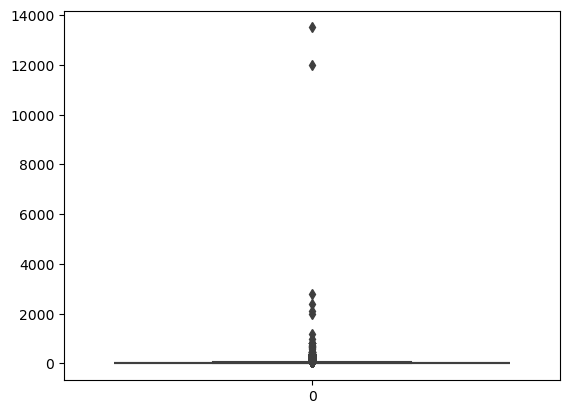

In [158]:
import seaborn as sns
sns.boxplot(data2['modal_price'])

In [159]:
data2.shape

(100000, 10)

In [160]:
data2['modal_price']

0         79.55
1         80.05
2        122.50
3        107.00
4         99.75
          ...  
99995     63.00
99996      5.00
99997     69.00
99998     30.20
99999     78.40
Name: modal_price, Length: 100000, dtype: float64

In [161]:
Q1=np.percentile(data2['modal_price'], 25,interpolation="midpoint")
Q3=np.percentile(data2['modal_price'], 75,interpolation="midpoint")
IQR = Q3-Q1

In [162]:
upper = np.where(data2['modal_price']>=(Q3+1.5*IQR))
lower = np.where(data2['modal_price']<=(Q1-1.5*IQR))

In [163]:
print(upper[0],lower[0])

[    0     1     2 ... 99986 99987 99999] []


In [164]:
data2.drop(upper[0],inplace = True)
data2.drop(lower[0],inplace = True)

print("new shape:",data2.shape)

new shape: (94494, 10)


In [165]:
#sns.boxplot(data2['modal_price'])


In [166]:
df=data2.copy()

In [167]:
data2.columns

Index(['commodity_name', 'state', 'district', 'market', 'min_price',
       'max_price', 'modal_price', 'month_column', 'season_names', 'day'],
      dtype='object')

In [168]:
import plotly.express as px

C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


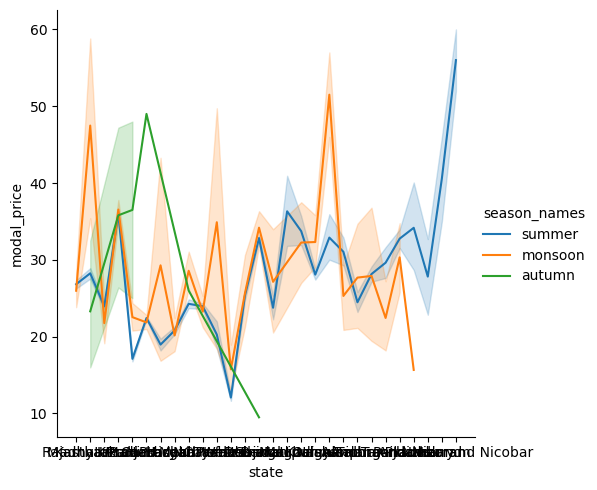

In [169]:
sns.relplot(data=df,x="state",y="modal_price",hue="season_names",kind="line")

C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


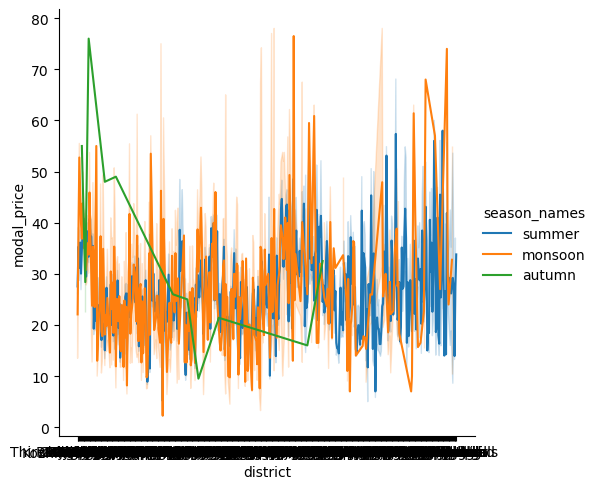

In [170]:
sns.relplot(data=df,x="district",y="modal_price",hue="season_names",kind="line")

In [171]:
fig = px.bar(df,x="district",y="modal_price",color="season_names",height=400)

C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



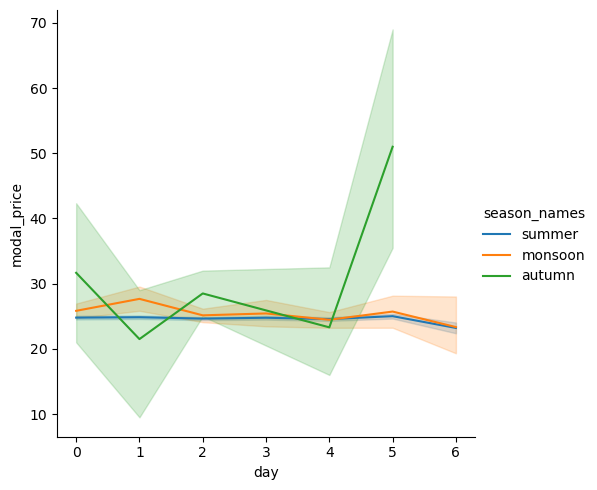

In [173]:
sns.relplot(data=df,x="day",y="modal_price",hue="season_names",kind="line")

In [174]:
data2.columns

Index(['commodity_name', 'state', 'district', 'market', 'min_price',
       'max_price', 'modal_price', 'month_column', 'season_names', 'day'],
      dtype='object')

C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



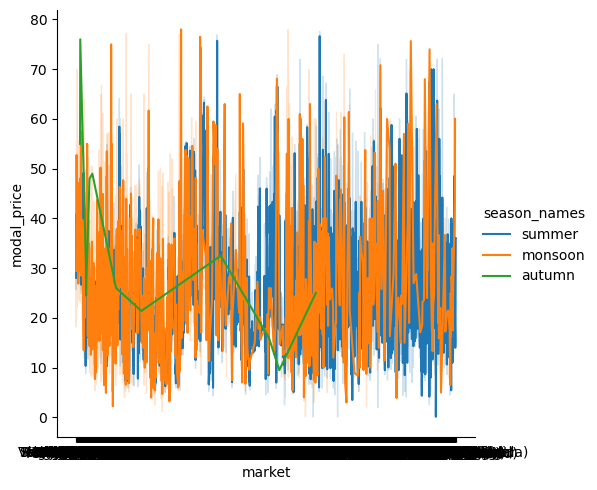

In [175]:
sns.relplot(data=df,x="market",y="modal_price",hue="season_names",kind="line")

C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



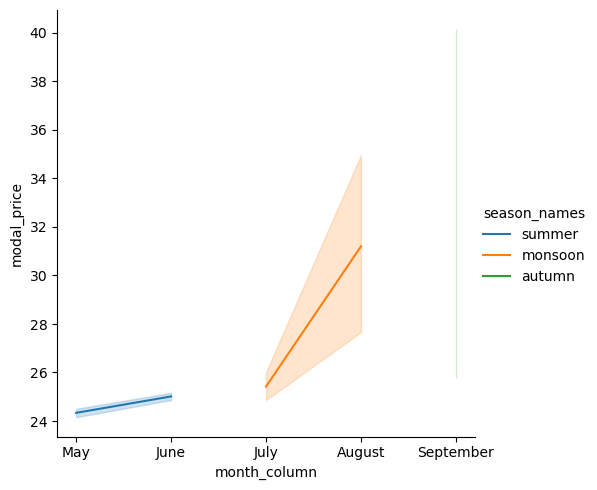

In [176]:
sns.relplot(data=df,x="month_column",y="modal_price",hue="season_names",kind="line")

In [177]:
dist=(data2['commodity_name'])
distset=set(dist)
dd=list(distset)
dictOfWords={dd[i]:i for i in range(0,len(dd))}
data2['commodity_name']=data2['commodity_name'].map(dictOfWords)

for commodity, numerical_value in dictOfWords.items():
    print(f"Commodity: {commodity} | Numerical Value: {numerical_value}")

Commodity: Cauliflower | Numerical Value: 0
Commodity: Kulthi(Horse+Gram) | Numerical Value: 1
Commodity: Paddy(Dhan)(Basmati) | Numerical Value: 2
Commodity: Ginger(Green) | Numerical Value: 3
Commodity: Onion | Numerical Value: 4
Commodity: Beetroot | Numerical Value: 5
Commodity: Colacasia | Numerical Value: 6
Commodity: Cotton | Numerical Value: 7
Commodity: Indian+Beans+(Seam) | Numerical Value: 8
Commodity: Mahua | Numerical Value: 9
Commodity: Rajgir | Numerical Value: 10
Commodity: Bitter+gourd | Numerical Value: 11
Commodity: Chapparad+Avare | Numerical Value: 12
Commodity: Sweet+Potato | Numerical Value: 13
Commodity: Tomato | Numerical Value: 14
Commodity: Egg | Numerical Value: 15
Commodity: Turmeric | Numerical Value: 16
Commodity: Green+Fodder | Numerical Value: 17
Commodity: Suva+(Dill+Seed) | Numerical Value: 18
Commodity: Knool+Khol | Numerical Value: 19
Commodity: Methi(Leaves) | Numerical Value: 20
Commodity: Peas(Dry) | Numerical Value: 21
Commodity: She+Goat | Nume

In [178]:
# Assuming you've already created the dictionary dictOfWords
data2


,commodity_name,state,district,market,min_price,max_price,modal_price,month_column,season_names,day
6,165,Rajasthan,Chittorgarh,Nimbahera,9.77,9.95,9.80,May,summer,2
8,72,Karnataka,Bagalkot,Bagalakot,46.01,46.50,46.46,May,summer,2
9,72,Karnataka,Bangalore,Bangalore,48.00,53.00,50.50,May,summer,2
10,72,Karnataka,Gadag,Laxmeshwar,22.15,46.41,36.54,May,summer,2
11,72,Madhya Pradesh,Panna,Ajaygarh,41.00,46.20,42.00,May,summer,2
...,...,...,...,...,...,...,...,...,...,...
99994,4,Uttar Pradesh,Badaun,Ujhani,11.50,12.70,12.10,June,summer,3
99995,3,Uttar Pradesh,Basti,Basti,62.00,64.00,63.00,June,summer,2
99996,4,Uttar Pradesh,Kanpur,Uttaripura,4.00,5.00,5.00,June,summer,3
99997,3,Uttar Pradesh,Gorakhpur,Chorichora,68.50,69.80,69.00,June,summer,2


In [179]:
dist=(data2['state'])
distset=set(dist)
dd=list(distset)
dictOfWords={dd[i]:i for i in range(0,len(dd))}
data2['state']=data2['state'].map(dictOfWords)
# Assuming you've already created the dictionary dictOfWords
for state, numerical_value in dictOfWords.items():
    print(f"State: {state} | Numerical Value: {numerical_value}")



State: Chattisgarh | Numerical Value: 0
State: Pondicherry | Numerical Value: 1
State: Madhya Pradesh | Numerical Value: 2
State: Tamil Nadu | Numerical Value: 3
State: Meghalaya | Numerical Value: 4
State: Gujarat | Numerical Value: 5
State: Uttrakhand | Numerical Value: 6
State: Odisha | Numerical Value: 7
State: Assam | Numerical Value: 8
State: Haryana | Numerical Value: 9
State: Karnataka | Numerical Value: 10
State: Maharashtra | Numerical Value: 11
State: Jammu and Kashmir | Numerical Value: 12
State: Nagaland | Numerical Value: 13
State: West Bengal | Numerical Value: 14
State: Andaman and Nicobar | Numerical Value: 15
State: Manipur | Numerical Value: 16
State: Rajasthan | Numerical Value: 17
State: NCT of Delhi | Numerical Value: 18
State: Punjab | Numerical Value: 19
State: Telangana | Numerical Value: 20
State: Jharkhand | Numerical Value: 21
State: Mizoram | Numerical Value: 22
State: Kerala | Numerical Value: 23
State: Tripura | Numerical Value: 24
State: Himachal Pradesh

C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\nikhi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



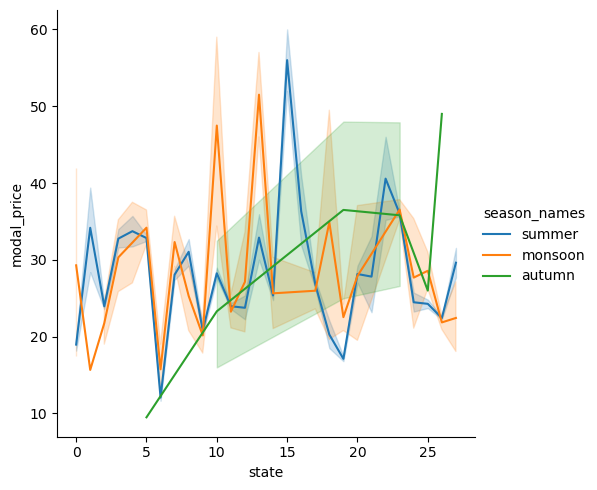

In [180]:
sns.relplot(data=data2,x="state",y="modal_price",hue="season_names",kind="line")

In [181]:
dist=(data2['district'])
distset=set(dist)
dd=list(distset)
dictOfWords={dd[i]:i for i in range(0,len(dd))}
data2['district']=data2['district'].map(dictOfWords)

for district, numerical_value in dictOfWords.items():
    print(f"district: {district} | Numerical Value: {numerical_value}")

district: Jashpur | Numerical Value: 0
district: Sivaganga | Numerical Value: 1
district: Jaunpur | Numerical Value: 2
district: Ajmer | Numerical Value: 3
district: Darjeeling | Numerical Value: 4
district: Auraiya | Numerical Value: 5
district: Nandurbar | Numerical Value: 6
district: Banda | Numerical Value: 7
district: Chandrapur | Numerical Value: 8
district: Idukki | Numerical Value: 9
district: Rajgarh | Numerical Value: 10
district: Surguja | Numerical Value: 11
district: Bharuch | Numerical Value: 12
district: Giridih | Numerical Value: 13
district: Firozabad | Numerical Value: 14
district: Vashim | Numerical Value: 15
district: Cuttack | Numerical Value: 16
district: Chittorgarh | Numerical Value: 17
district: Udaipur | Numerical Value: 18
district: Barpeta | Numerical Value: 19
district: Ramanathapuram | Numerical Value: 20
district: Beed | Numerical Value: 21
district: Ganganagar | Numerical Value: 22
district: Ropar (Rupnagar) | Numerical Value: 23
district: Chhindwara | N

In [182]:
dist=(data2['market'])
distset=set(dist)
dd=list(distset)
dictOfWords={dd[i]:i for i in range(0,len(dd))}
data2['market']=data2['market'].map(dictOfWords)
for market, numerical_value in dictOfWords.items():
    print(f"market: {market} | Numerical Value: {numerical_value}")

market: Munnar | Numerical Value: 0
market: Uchana | Numerical Value: 1
market: Maksi | Numerical Value: 2
market: Kuchinda | Numerical Value: 3
market: Shajapur(F&V) | Numerical Value: 4
market: Bilsi | Numerical Value: 5
market: Bharuch | Numerical Value: 6
market: Jangipur | Numerical Value: 7
market: Mohanpur | Numerical Value: 8
market: Naushera Pannuan | Numerical Value: 9
market: Channagiri | Numerical Value: 10
market: Patran | Numerical Value: 11
market: Chittorgarh | Numerical Value: 12
market: Talod | Numerical Value: 13
market: Shahzadpur | Numerical Value: 14
market: Pabiacherra | Numerical Value: 15
market: Lonar | Numerical Value: 16
market: Wyra | Numerical Value: 17
market: Samana | Numerical Value: 18
market: Panvel | Numerical Value: 19
market: Dimapur | Numerical Value: 20
market: Pataudi | Numerical Value: 21
market: Bampada | Numerical Value: 22
market: Bhanvad | Numerical Value: 23
market: Buldhana | Numerical Value: 24
market: Perinthalmanna | Numerical Value: 2

In [183]:
dist=(data2['month_column'])
distset=set(dist)
dd=list(distset)
dictOfWords={dd[i]:i for i in range(0,len(dd))}
data2['month_column']=data2['month_column'].map(dictOfWords)

# Assuming you've already created the dictionary dictOfWords
for month, numerical_value in dictOfWords.items():
    print(f"State: {month} | Numerical Value: {numerical_value}")


State: May | Numerical Value: 0
State: August | Numerical Value: 1
State: July | Numerical Value: 2
State: June | Numerical Value: 3
State: September | Numerical Value: 4


In [184]:
dist=(data2['season_names'])
distset=set(dist)
dd=list(distset)
dictOfWords={dd[i]:i for i in range(0,len(dd))}
data2['season_names']=data2['season_names'].map(dictOfWords)

In [185]:
data2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 94494 entries, 6 to 99998
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   commodity_name  94494 non-null  int64  
 1   state           94494 non-null  int64  
 2   district        94494 non-null  int64  
 3   market          94494 non-null  int64  
 4   min_price       94494 non-null  float64
 5   max_price       94494 non-null  float64
 6   modal_price     94494 non-null  float64
 7   month_column    94494 non-null  int64  
 8   season_names    94494 non-null  int64  
 9   day             94494 non-null  int64  
dtypes: float64(3), int64(7)
memory usage: 9.9 MB


In [186]:
import matplotlib.pyplot as plt

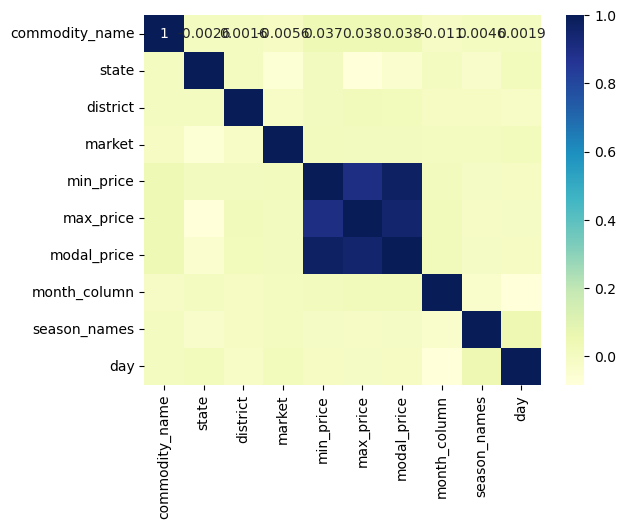

In [187]:
dataplot=sns.heatmap(data2.corr(),cmap ="YlGnBu",annot=True)
plt.show()

In [188]:
features=data2[['commodity_name','state','district','market','month_column','season_names','day']]
labels=data2['modal_price']

In [189]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,Ytrain,Ytest=train_test_split(features,labels,test_size=0.2,random_state=2)

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn import tree

In [191]:
from sklearn.ensemble import RandomForestRegressor
import joblib

# Assume Xtrain and Ytrain are already defined
regr = RandomForestRegressor(max_depth=1000, random_state=0)
regr.fit(Xtrain, Ytrain)

# Save the model to a file
joblib.dump(regr, 'random_forest_model1.joblib')


['random_forest_model1.joblib']

In [192]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.datasets import make_regression

# regr=RandomForestRegressor(max_depth=1000,random_state=0)
# regr.fit(Xtrain,Ytrain)

In [193]:
Xtest[0:1]

,commodity_name,state,district,market,month_column,season_names,day
6857,79,26,82,68,0,2,2


In [194]:
y_pred=regr.predict(Xtest)

In [195]:
Xtest

,commodity_name,state,district,market,month_column,season_names,day
6857,79,26,82,68,0,2,2
97785,111,26,146,706,3,2,4
93327,153,25,314,308,2,1,0
86378,30,19,31,1537,3,2,3
15674,54,5,419,155,0,2,4
...,...,...,...,...,...,...,...
32752,116,5,419,1017,0,2,1
57950,61,25,430,168,3,2,5
99201,88,19,255,244,3,2,3
20089,161,7,103,443,0,2,0


In [196]:
from sklearn.metrics import r2_score

In [197]:
r2_score(Ytest,y_pred)

0.9185079892793616

In [198]:
y_pred

array([ 9.78183333, 23.07085   ,  6.39272619, ..., 43.62321429,
       46.45306667, 13.052     ])

In [199]:
Xtest[0:1]

,commodity_name,state,district,market,month_column,season_names,day
6857,79,26,82,68,0,2,2


In [200]:
user_input=[[156,18,194,1512,2,1,2]]
regr.predict(user_input)

C:\Users\nikhi\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names



array([15.21086667])